<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/scrna/02_normalizasyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normalizasyon ve değişken gen seçimi

Bu defterde üç iş yapıyoruz: veriyi Zenodo DOI'sinden okumak, hücreler arasındaki dizileme derinliği farkını normalizasyonla gidermek ve kümeleme için bilgi taşıyan değişken genleri seçmek. Her adımda hangi fonksiyonun ne yaptığını ve parametrelerin ne anlama geldiğini açıklıyorum.

In [1]:
%pip install -q scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


## 1. Veriyi okumak

`scanpy`, tek hücre RNA-seq analizinin standart Python kütüphanesi. `urllib.request.urlretrieve(url, dosya_adi)` verilen adresteki dosyayı diske indirir; adresimiz 2.1'de Zenodo'ya yüklediğim kaydın kalıcı indirme bağlantısı.

`sc.read_h5ad()` bir **AnnData** nesnesi döndürür. AnnData, tek hücre verisinin standart kabıdır ve dört parçasını bu seride sürekli kullanacağız:

- `a.X`: hücre × gen sayım matrisi (satır hücre, sütun gen)
- `a.obs`: hücre başına bilgi tablosu — 2.1'de hesapladığımız kalite ölçüleri (`total_counts`, `n_genes_by_counts`, `pct_counts_mt`) burada duruyor
- `a.var`: gen başına bilgi tablosu (gen adları, Ensembl kimlikleri)
- `a.layers`: matrisin adlandırılmış kopyaları için sözlük; birazdan kullanacağız

`.h5ad` uzantısı, AnnData'nın HDF5 tabanlı dosya biçimidir.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import numpy as np

urllib.request.urlretrieve('https://zenodo.org/records/22655336/files/pbmc3k_ders.h5ad?download=1', 'pbmc3k_ders.h5ad')
a = sc.read_h5ad('pbmc3k_ders.h5ad')
print('Kaynak DOI: 10.5281/zenodo.22655336 | hücre × gen:', a.shape)

Kaynak DOI: 10.5281/zenodo.22655336 | hücre × gen: (2694, 13714)


## 2. Derinlik farkını ölçmek

`a.obs.total_counts` her hücrede sayılan toplam UMI'dir; `min()`, `median()`, `max()` ile aralığına bakıyoruz. Bu fark biyoloji değil tekniktir: damlacık tabanlı protokollerde her hücreden eşit miktarda molekül yakalanmaz.

`a.X` **seyrek matris** olarak tutulur: yalnız sıfırdan farklı değerler bellekte saklanır. `X.nnz` sıfır olmayan hücre-gen çiftlerinin sayısıdır; toplam göz sayısına bölünce matrisin doluluk oranı çıkar.

Son satır şunu sayar: `(X > 0).sum(axis=0)` her genin kaç hücrede sıfırdan büyük olduğunu verir; bunu hücre sayısıyla karşılaştırınca **her** hücrede ifade edilen genleri buluruz. Bu sayı önemli, çünkü birinci serideki medyan-oran normalizasyonunun referansı, her örnekte sıfırdan büyük olan genlerden kurulur — geometrik ortalama sıfır kabul etmez. Toplu veride bu koşulu 18.470 gen sağlıyordu; burada kaç genin sağladığını göreceksiniz. Sonuç, o yöntemin tek hücre verisine neden doğrudan uygulanamadığının kanıtıdır.

In [3]:
tc = a.obs.total_counts
print('Toplam UMI min / medyan / maks:', int(tc.min()), '/', int(tc.median()), '/', int(tc.max()))
print('En derin hücre, en sığın %.1f katı' % (tc.max() / tc.min()))

X = a.X
print('Matris doluluğu: %%%.2f' % (100 * X.nnz / (X.shape[0] * X.shape[1])))
tam = np.asarray((X > 0).sum(axis=0)).ravel() == X.shape[0]
print('Her hücrede sıfırdan büyük olan gen:', a.var_names[tam].tolist())

Toplam UMI min / medyan / maks: 548 / 2200 / 15844
En derin hücre, en sığın 28.9 katı
Matris doluluğu: %6.17
Her hücrede sıfırdan büyük olan gen: ['TMSB4X']


## 3. Normalizasyon ve log dönüşümü

Sırasıyla üç işlem:

1. `a.layers['sayim'] = a.X.copy()` — ham sayımların bir kopyasını `sayim` adlı katmana koyar. Neden: bazı yöntemler (örneğin ileride diferansiyel ifade) ham sayım ister; ham veri asla üzerine yazılarak kaybedilmez.
2. `sc.pp.normalize_total(a, target_sum=1e4)` — her hücrenin bütün değerlerini o hücrenin toplamına böler ve 10.000 ile çarpar. Sonuç "10.000 sayım başına ifade"dir (CP10K). `target_sum` sadece bir ölçek sabitidir; 10.000 alanın yerleşik tercihi. Bu işlem hücreler arası derinlik farkını kaldırır; sınırı da bilin: hücre kompozisyonundaki gerçek farkları modellemez, yalnız toplamı eşitler.
3. `sc.pp.log1p(a)` — her değere doğal logaritma(x + 1) uygular. +1, sıfırların log'unu tanımlı kılmak için; log ise sağa çarpık sayım dağılışını sıkıştırıp yüksek ve düşük ifadeli genleri aynı ölçekte karşılaştırılabilir yapmak için.

In [4]:
a.layers['sayim'] = a.X.copy()

sc.pp.normalize_total(a, target_sum=1e4)
s = np.asarray(a.X.sum(axis=1)).ravel()
print('Normalize sonrası ilk 3 hücre toplamı:', s[:3].round(1))

sc.pp.log1p(a)
print("log1p uygulandı; ham sayımlar a.layers['sayim'] içinde duruyor")

Normalize sonrası ilk 3 hücre toplamı: [10000. 10000. 10000.]
log1p uygulandı; ham sayımlar a.layers['sayim'] içinde duruyor


## 4. Değişken gen seçimi

Amaç: 13.714 genin içinden, hücreden hücreye anlamlı biçimde değişenleri işaretlemek. Hücreler arasında değişmeyen bir gen, hücre tiplerini ayırmak için bilgi taşımaz; onları hesaba katmak yalnız gürültü ve işlem yükü ekler.

`sc.pp.highly_variable_genes(a, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)` şunu yapar: her gen için log-normalize veride ortalama ve **dispersiyon** (varyans/ortalama) hesaplar; genleri ortalama düzeylerine göre kutulara ayırıp dispersiyonu kutu içinde standartlaştırır (`dispersions_norm`); sonra üç eşiği uygular:

- `min_mean=0.0125`: ortalaması bunun altındaki genler elenir — bu kadar az ifade edilen genlerde değişkenlik ölçümü güvenilmezdir
- `max_mean=3`: ortalaması bunun üstündeki genler elenir — çok yüksek ifadeli genlerde dispersiyon kestirimi sistematik olarak farklı davranır
- `min_disp=0.5`: standartlaştırılmış dispersiyonu bunun üstünde kalanlar bayrak alır — yani kendi ifade düzeyi için beklenenden daha değişken olanlar

Sonuç `a.var.highly_variable` sütununa True/False olarak yazılır. Gen silinmez, işaretlenir; bir sonraki rehberde PCA yalnız bayraklı genleri kullanacak. `sc.pl.highly_variable_genes(a)` seçimi gösterir: x ekseni ortalama, y ekseni dispersiyon, koyu noktalar bayrak alanlar.

Değişken bayrağı alan gen: 1860


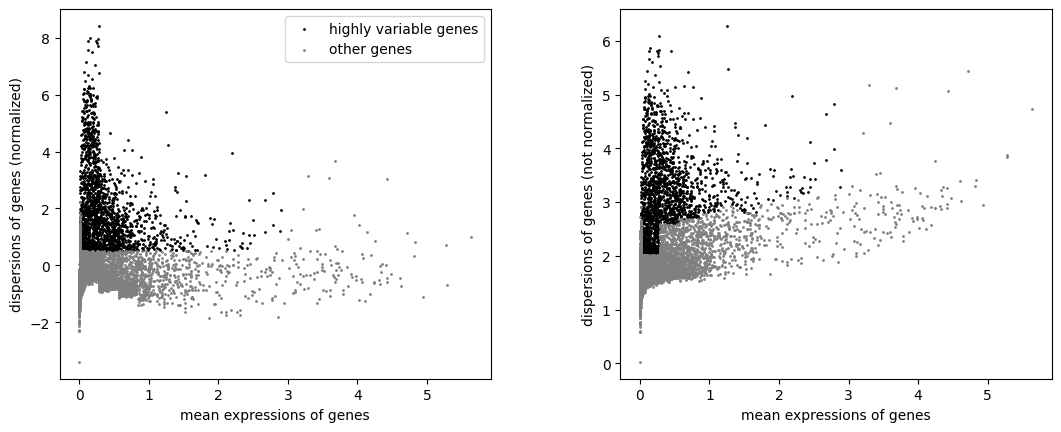

In [5]:
sc.pp.highly_variable_genes(a, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
print('Değişken bayrağı alan gen:', int(a.var.highly_variable.sum()))
sc.pl.highly_variable_genes(a)

## Kendin dene

Üç görev. Birincisi: kendi koşunuzdan toplam UMI'nin min/medyan/maks değerlerini, en derin/en sığ oranını ve matris doluluğunu not edin. İkincisi: 2. bölümdeki "her hücrede sıfırdan büyük gen" çıktınıza dayanarak tek cümle yazın — medyan-oran normalizasyonu bu veriye neden doğrudan uygulanamıyor? Üçüncüsü: `panel = ['LYZ','GNLY','PPBP','MS4A1','CD3D','NKG7','CD14','FCGR3A']` için `a.var.loc[panel, ['means','highly_variable']]` tablosunu basın; kaç gen bayraklı, bayrak alamayanlardan ortalaması en yüksek olan hangisi ve hangi eşiğe takılmış — `means` sütununu yukarıdaki üç eşikle karşılaştırarak tek cümleyle açıklayın.